In [18]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

nodes_df = pd.read_csv("./pre_processing_output/classification_three_labels_nodes.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("./pre_processing_output/edges.csv")  # Dataset con interazioni proteina-proteina

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
print(nodes_df['label'])
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.long))

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))

edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.int)

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])  # Multilabel target
)

print(data)


0      0
1      0
2      0
3      0
4      0
      ..
174    1
175    1
176    1
177    1
178    1
Name: label, Length: 179, dtype: int64
Data(x=[179, 200], edge_index=[2, 666], y=[179])


/tmp/ipykernel_8265/1685591108.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=3, dropout=0):
        super(GCN, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels // 2, out_channels)

        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x  # Output logits for CrossEntropyLoss
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x, data.edge_index)
            train_loss = criterion(out[data.train_mask], data.y[data.train_mask])
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x, data.edge_index)
                val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        plt.figure()
        plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
        plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training & Validation Loss Curve')
        plt.legend()
        plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=100, learning_rate=0.001, patience=10):
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None

        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x, data.y.cpu().numpy())):
            print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = ~train_mask

            model = GCN(in_channels=self.conv1.in_channels, 
                        hidden_channels=self.conv2.out_channels, 
                        out_channels=self.conv3.out_channels, 
                        dropout=self.dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.CrossEntropyLoss()
            model.train_model(data, optimizer, criterion, epochs, patience)

            model.eval()
            with torch.no_grad():
                out = model(data.x, data.edge_index)
                pred = out[data.val_mask].argmax(dim=1)
                y_true = data.y[data.val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred, average='macro')
                recall = recall_score(y_true, y_pred, average='macro')
                f1 = f1_score(y_true, y_pred, average='macro')
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                print(f"Accuracy: {acc:.4f}")
                print(f"Precision: {precision:.4f}")
                print(f"Recall: {recall:.4f}")
                print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1
                    }
                    best_cm = cm

        print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
        print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
        print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
        print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
        print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
        
        return best_model



🔹 Fold 1/5
Epoch 0, Train Loss: 6.8089, Val Loss: 6.9308, LR: 0.001000
Epoch 10, Train Loss: 2.0464, Val Loss: 1.9377, LR: 0.001000
Epoch 20, Train Loss: 1.1846, Val Loss: 1.2022, LR: 0.001000
Epoch 30, Train Loss: 0.9788, Val Loss: 1.0279, LR: 0.001000
Early stopping triggered at epoch 35


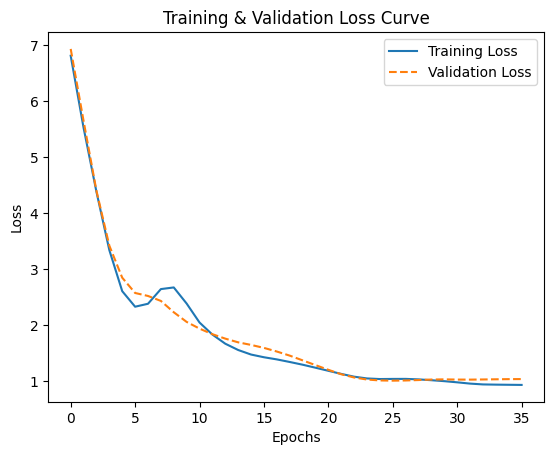

Accuracy: 0.5278
Precision: 0.3590
Recall: 0.3520
F1-Score: 0.3382

🔹 Fold 2/5
Epoch 0, Train Loss: 2.7408, Val Loss: 1.9658, LR: 0.001000
Epoch 10, Train Loss: 1.0310, Val Loss: 1.1325, LR: 0.001000
Epoch 20, Train Loss: 0.8399, Val Loss: 1.0155, LR: 0.001000
Epoch 30, Train Loss: 0.7925, Val Loss: 0.9651, LR: 0.000500
Epoch 40, Train Loss: 0.7609, Val Loss: 0.9654, LR: 0.000250
Early stopping triggered at epoch 42


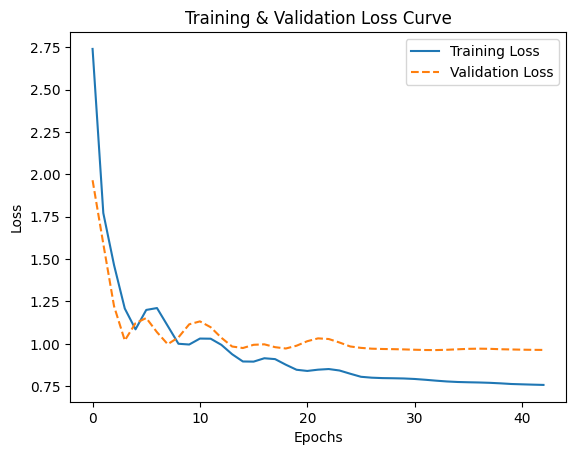

Accuracy: 0.5278
Precision: 0.3423
Recall: 0.3614
F1-Score: 0.3492

🔹 Fold 3/5
Epoch 0, Train Loss: 4.6413, Val Loss: 4.5797, LR: 0.001000


/home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 10, Train Loss: 1.3986, Val Loss: 1.2809, LR: 0.001000
Epoch 20, Train Loss: 1.0587, Val Loss: 1.0978, LR: 0.001000
Epoch 30, Train Loss: 0.8610, Val Loss: 0.9060, LR: 0.001000
Epoch 40, Train Loss: 0.8128, Val Loss: 0.8861, LR: 0.001000


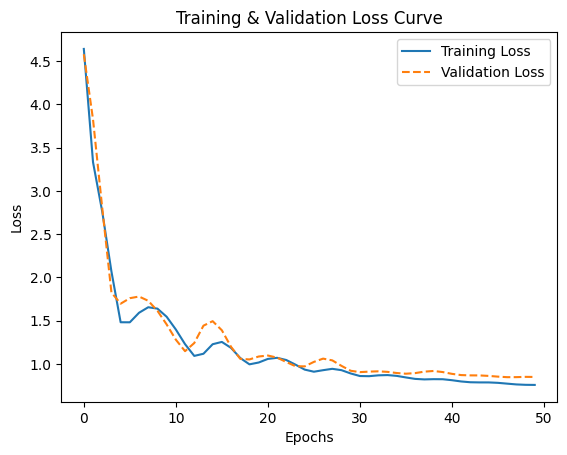

Accuracy: 0.5278
Precision: 0.6722
Recall: 0.4704
F1-Score: 0.5152

🔹 Fold 4/5
Epoch 0, Train Loss: 4.4319, Val Loss: 3.2543, LR: 0.001000
Epoch 10, Train Loss: 1.1497, Val Loss: 1.2804, LR: 0.001000
Epoch 20, Train Loss: 0.9036, Val Loss: 1.0537, LR: 0.001000
Epoch 30, Train Loss: 0.8333, Val Loss: 1.0132, LR: 0.001000
Epoch 40, Train Loss: 0.7604, Val Loss: 0.9941, LR: 0.001000


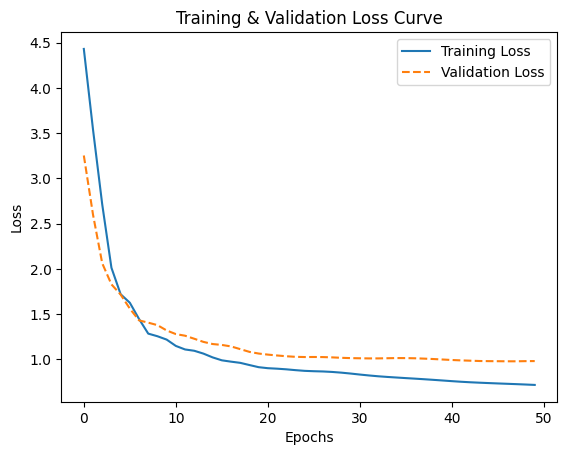

Accuracy: 0.5278
Precision: 0.3552
Recall: 0.3741
F1-Score: 0.3554

🔹 Fold 5/5
Epoch 0, Train Loss: 5.0961, Val Loss: 2.9498, LR: 0.001000
Epoch 10, Train Loss: 1.3547, Val Loss: 1.0812, LR: 0.001000
Epoch 20, Train Loss: 0.9562, Val Loss: 1.0538, LR: 0.000500
Early stopping triggered at epoch 21


/home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


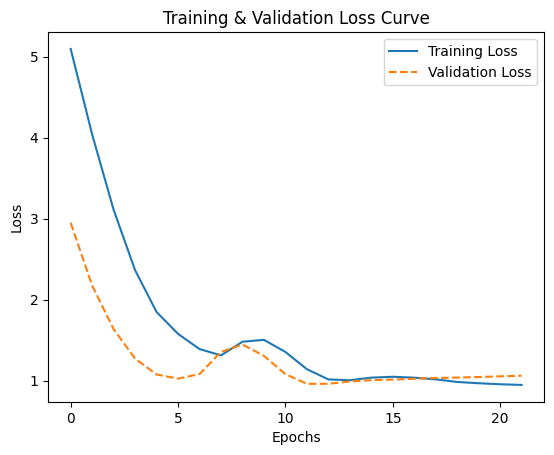

Accuracy: 0.4286
Precision: 0.3911
Recall: 0.4407
F1-Score: 0.4068

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.5079 ± 0.0397
Precision: 0.4239 ± 0.1252
Recall: 0.3997 ± 0.0471
F1-Score: 0.3930 ± 0.0655


In [20]:
from torch.optim import Adam

LR = 0.001

model = GCN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=3, dropout=0)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)

best = model.k_fold_cross_validation(data, epochs=50, learning_rate=LR, patience=10)